# Results: Automated Analysis of Policy Briefs

Automated extraction and classification results across a corpus of European forest and biodiversity research policy briefs. Results are structured along the original **coding framework** covering seven thematic dimensions (A–H), plus five theory-informed policy-instrument frames (H19–H24).

Section 2 establishes extraction quality via cross-validation against manually coded segments before the substantive framework results.

**Sections:**
1. Corpus Description
2. AI Extraction Quality (Cross-Validation)
3. Content Structure (B)
4. Action Orientation (C & D)
5. Accessibility (E)
6. Narrative & Transparency (F & G)
7. Policy-Instrument Frames (H)

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

C_PRIMARY   = '#2F6B7C'
C_SECONDARY = '#3AAFA9'
C_ACCENT    = '#F4A261'
C_WARM      = '#E76F51'
C_AGREE     = '#4DB6AC'
C_DISAGREE  = '#EF9A9A'

OUTPUT_DIR   = Path.cwd() / 'output'
CROSSVAL_DIR = OUTPUT_DIR / 'crossval'

def _load(name):
    p = OUTPUT_DIR / name
    if not p.exists():
        print(f'warning: {name} not found')
        return pd.DataFrame()
    return pd.read_csv(p)

def _col(df, col, default=None):
    return df[col] if col in df.columns else pd.Series(default, index=df.index, name=col)

def _has_col(df, col):
    return col in df.columns

documents       = _load('documents.csv')
frames          = _load('frames.csv')
recommendations = _load('recommendations.csv')
structural_core = _load('structural_core.csv')

_cv  = CROSSVAL_DIR / 'metrics.json'
_cmp = CROSSVAL_DIR / 'comparison.csv'
crossval_metrics = json.loads(_cv.read_text())  if _cv.exists()  else {}
comparison_df    = pd.read_csv(_cmp)             if _cmp.exists() else pd.DataFrame()

# ── Build document-level analysis_df ─────────────────────────────────
analysis_df = documents[['doc_id']].copy()
analysis_df['A1_page_count'] = documents['page_count']

sc = structural_core.set_index('doc_id') if len(structural_core) else pd.DataFrame()
if len(sc):
    analysis_df['B2_problem_identified']    = analysis_df['doc_id'].map(sc['problem_status']).fillna('absent')
    analysis_df['B3_solutions_explicit']    = analysis_df['doc_id'].map(sc['solutions_explicit']).fillna(False)
    analysis_df['B3_solutions_count']       = analysis_df['doc_id'].map(sc['solutions_count']).fillna(0).astype(int)
    analysis_df['B4_implementation_status'] = analysis_df['doc_id'].map(sc['implementation_status']).fillna('absent')

if len(sc) and 'procedural_clarity_status' in sc.columns:
    analysis_df['C5_procedural_clarity'] = analysis_df['doc_id'].map(sc['procedural_clarity_status']).fillna('absent')
elif 'B4_implementation_status' in analysis_df.columns:
    analysis_df['C5_procedural_clarity'] = analysis_df['B4_implementation_status']

if len(recommendations):
    has_actor      = recommendations.dropna(subset=['actor_raw']).groupby('doc_id').size().gt(0)
    has_actor_resp = recommendations[recommendations['extraction_type'] == 'actor_responsibility'].groupby('doc_id').size().gt(0)
    analysis_df['C6_responsibility']       = analysis_df['doc_id'].map(has_actor | has_actor_resp).fillna(False)
    has_outcome    = recommendations[recommendations['extraction_type'] == 'expected_outcome'].groupby('doc_id').size().gt(0)
    analysis_df['C7_anticipated_outcomes'] = analysis_df['doc_id'].map(has_outcome).fillna(False)
    analysis_df['D8_impacts_proxy']        = analysis_df['C7_anticipated_outcomes']
    has_tradeoff   = recommendations[recommendations['extraction_type'] == 'trade_off'].groupby('doc_id').size().gt(0)
    analysis_df['D9_tradeoffs']            = analysis_df['doc_id'].map(has_tradeoff).fillna(False)
    has_policy_opt = recommendations[recommendations['extraction_type'] == 'policy_option'].groupby('doc_id').size().gt(0)
    analysis_df['D10_policy_options']      = analysis_df['doc_id'].map(has_policy_opt).fillna(False)

if _has_col(documents, 'passive_voice_share'):
    analysis_df['E11_passive_voice_share'] = documents['passive_voice_share']
analysis_df['E12_avg_sentence_length']  = documents['avg_sentence_length']
analysis_df['E13_lexical_diversity']    = documents['lexical_diversity']
analysis_df['E14_flesch_reading_ease']  = _col(documents, 'flesch_reading_ease',  np.nan)
analysis_df['E14_flesch_kincaid_grade'] = _col(documents, 'flesch_kincaid_grade', np.nan)

if len(sc):
    analysis_df['F15_narrative_hook'] = analysis_df['doc_id'].map(sc['narrative_hook_present']).fillna(False)
    analysis_df['F15_hook_type']      = analysis_df['doc_id'].map(sc['narrative_hook_type'])

analysis_df['G16_funding'] = (
    documents['funding_statement_present']
    if _has_col(documents, 'funding_statement_present')
    else np.nan
)
analysis_df['G18_contact_info'] = (
    documents['fm_emails'].notna() | documents['fm_urls'].notna() | documents['fm_authors'].notna()
)

if len(frames):
    _pf = frames[frames['decision'] == 'present']
    _fp = _pf.assign(v=1).pivot_table(index='doc_id', columns='frame_label', values='v', fill_value=0)
    for _fc in _fp.columns:
        _safe = _fc.replace(' ', '_').replace('-', '_')
        analysis_df[f'H_{_safe}'] = analysis_df['doc_id'].map(_fp[_fc]).fillna(0).astype(int)
    analysis_df['H_frames_present_count'] = (
        analysis_df['doc_id'].map(_pf.groupby('doc_id').size()).fillna(0).astype(int)
    )

analysis_df['H24_policy_mix'] = _col(documents, 'policy_mix_present', False)

print(f'Corpus: {len(analysis_df)} documents, {analysis_df.shape[1] - 1} framework indicators ready')

Corpus: 154 documents, 27 framework indicators ready


## 1. Corpus Description

The corpus consists of policy briefs from European forest and biodiversity research projects processed by the automated extraction pipeline. Table 1 reports the number of extraction records per output file; Figure 1 shows the distribution of document length (pages and words), which reflects the scope of content available for analysis.

**Table 1 — Extraction pipeline output sizes**

,Rows,Unique documents
Output file,,
documents.csv,154,154
structural_core.csv,154,154
recommendations.csv,1534,152
frames.csv,770,154


**Table 2 — Document length summary statistics**

,mean,median,std,min,max
Pages,26.2,11.0,37.8,2.0,187.0
Words,8736.1,3120.0,13311.2,438.0,76556.0


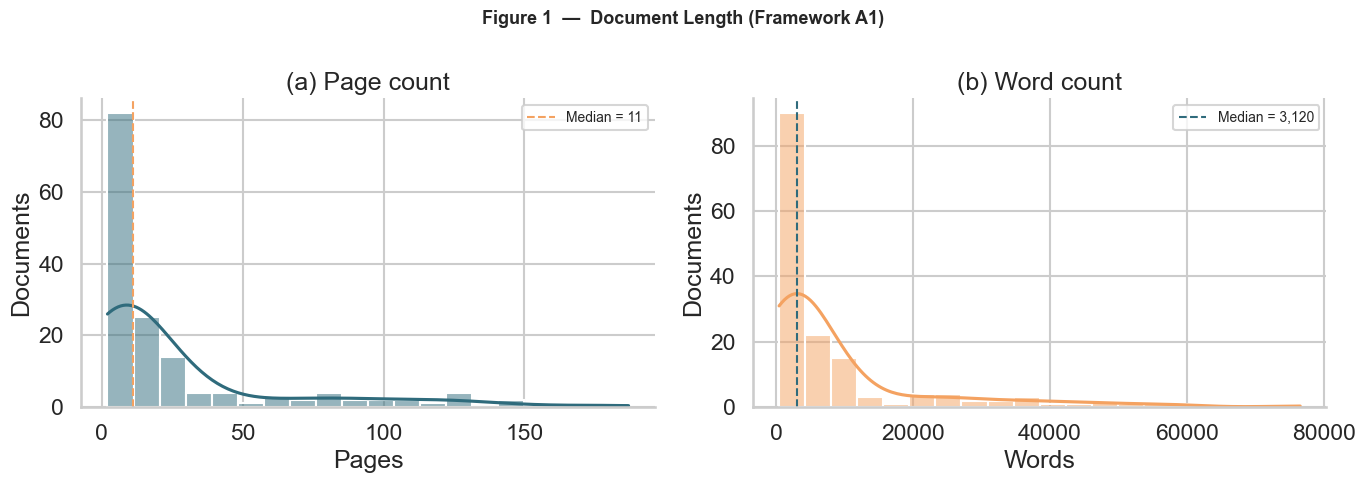

In [2]:
display(Markdown('**Table 1 — Extraction pipeline output sizes**'))
display(pd.DataFrame({
    'Output file': ['documents.csv', 'structural_core.csv', 'recommendations.csv', 'frames.csv'],
    'Rows': [len(documents), len(structural_core), len(recommendations), len(frames)],
    'Unique documents': [
        documents['doc_id'].nunique()       if len(documents)       else 0,
        structural_core['doc_id'].nunique() if len(structural_core) else 0,
        recommendations['doc_id'].nunique() if len(recommendations) else 0,
        frames['doc_id'].nunique()          if len(frames)          else 0,
    ],
}).set_index('Output file'))

_desc = (
    documents[['page_count', 'word_count']]
    .rename(columns={'page_count': 'Pages', 'word_count': 'Words'})
    .describe()
    .loc[['mean', '50%', 'std', 'min', 'max']]
    .rename(index={'50%': 'median'})
    .round(1)
)
display(Markdown('**Table 2 — Document length summary statistics**'))
display(_desc.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(analysis_df['A1_page_count'], bins=20, kde=True, ax=axes[0], color=C_PRIMARY)
axes[0].set_title('(a) Page count')
axes[0].set_xlabel('Pages')
axes[0].set_ylabel('Documents')
_med_p = analysis_df['A1_page_count'].median()
axes[0].axvline(_med_p, color=C_ACCENT, linestyle='--', linewidth=1.5, label=f'Median = {_med_p:.0f}')
axes[0].legend(fontsize=10)

if _has_col(documents, 'word_count'):
    sns.histplot(documents['word_count'].dropna(), bins=20, kde=True, ax=axes[1], color=C_ACCENT)
    axes[1].set_title('(b) Word count')
    axes[1].set_xlabel('Words')
    axes[1].set_ylabel('Documents')
    _med_w = documents['word_count'].median()
    axes[1].axvline(_med_w, color=C_PRIMARY, linestyle='--', linewidth=1.5, label=f'Median = {_med_w:,.0f}')
    axes[1].legend(fontsize=10)

fig.suptitle('Figure 1  —  Document Length (Framework A1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. AI Extraction Quality: Cross-Validation

Extraction quality was assessed by comparing AI-extracted solution segments against **1,333 manually coded segments** across **106 documents**. Three agreement metrics are reported:

- **Presence agreement (A)**: do AI and manual coders agree on whether a document contains solutions at all?
- **Dominant-type agreement (B)**: among documents where both find solutions, does the most frequent extraction type match the manually assigned type?
- **Content overlap — exact (C)**: is the normalized text of a manual segment present as a substring in any AI extraction for the same document (or vice versa)?

Figure 2(a) shows the three metrics; Figure 2(b) compares AI vs. manual solution counts per document, colored by presence agreement. Points above the 1:1 diagonal indicate the AI found more solutions than the manual coder.

AI solutions extracted:          1,642
Manually coded segments:         1,333
Documents with AI solutions:     151
Documents with manual solutions: 106


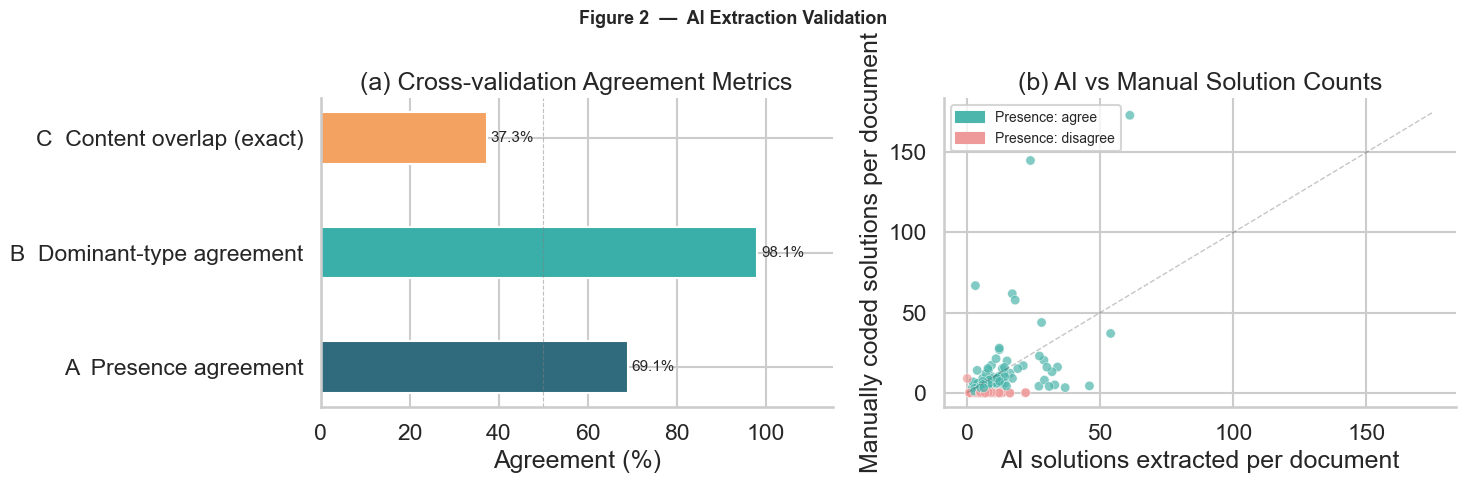

In [3]:
pov  = crossval_metrics.get('primary', {})
ov   = pov.get('overview', {})
pres = pov.get('presence_agreement', {})
typ  = pov.get('type_agreement', {})
ov_e = pov.get('overlap_exact', {})

print(f"AI solutions extracted:          {ov.get('ai_total_solutions',  'n/a'):,}")
print(f"Manually coded segments:         {ov.get('manual_total_solutions', 'n/a'):,}")
print(f"Documents with AI solutions:     {ov.get('ai_solution_docs',    'n/a')}")
print(f"Documents with manual solutions: {ov.get('manual_solution_docs','n/a')}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Agreement metrics horizontal bar
metrics_data = {
    'A  Presence agreement':       pres.get('rate', 0),
    'B  Dominant-type agreement':  typ.get('rate', 0),
    'C  Content overlap (exact)':  ov_e.get('overlap_rate', 0),
}
bar_colors = [C_PRIMARY, C_SECONDARY, C_ACCENT]
bars = axes[0].barh(
    list(metrics_data.keys()),
    [v * 100 for v in metrics_data.values()],
    color=bar_colors, edgecolor='white', height=0.45,
)
for bar, val in zip(bars, metrics_data.values()):
    axes[0].text(
        bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
        f'{val:.1%}', va='center', fontsize=11,
    )
axes[0].set_xlim(0, 115)
axes[0].axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_xlabel('Agreement (%)')
axes[0].set_title('(a) Cross-validation Agreement Metrics')

# (b) Scatter: AI vs manual solution counts (jittered)
if len(comparison_df):
    rng  = np.random.default_rng(42)
    jit  = 0.25
    ai_j  = comparison_df['ai_count']     + rng.uniform(-jit, jit, len(comparison_df))
    man_j = comparison_df['manual_count'] + rng.uniform(-jit, jit, len(comparison_df))
    c_pts = comparison_df['presence_agree'].map({True: C_AGREE, False: C_DISAGREE})
    axes[1].scatter(ai_j, man_j, c=c_pts, alpha=0.7, s=45, edgecolors='white', linewidths=0.4)
    _hi = max(comparison_df['ai_count'].max(), comparison_df['manual_count'].max()) + 2
    axes[1].plot([0, _hi], [0, _hi], 'k--', alpha=0.25, linewidth=1)
    axes[1].set_xlabel('AI solutions extracted per document')
    axes[1].set_ylabel('Manually coded solutions per document')
    axes[1].set_title('(b) AI vs Manual Solution Counts')
    p1 = mpatches.Patch(color=C_AGREE,    label='Presence: agree')
    p2 = mpatches.Patch(color=C_DISAGREE, label='Presence: disagree')
    axes[1].legend(handles=[p1, p2], fontsize=10)

fig.suptitle('Figure 2  —  AI Extraction Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Content Structure (Framework B)

Dimensions B2–B4 form the structural backbone of a policy brief: problem identification, explicit solutions, and implementation considerations. Together they assess whether the brief fulfils the basic communicative function of a policy document — presenting a problem and a plausible pathway toward addressing it.

| Dimension | Indicator | Values |
|---|---|---|
| B2 | Problem identified | present / weak / absent |
| B3 | Solutions explicit | yes / no |
| B4 | Implementation discussed | present / weak / absent |

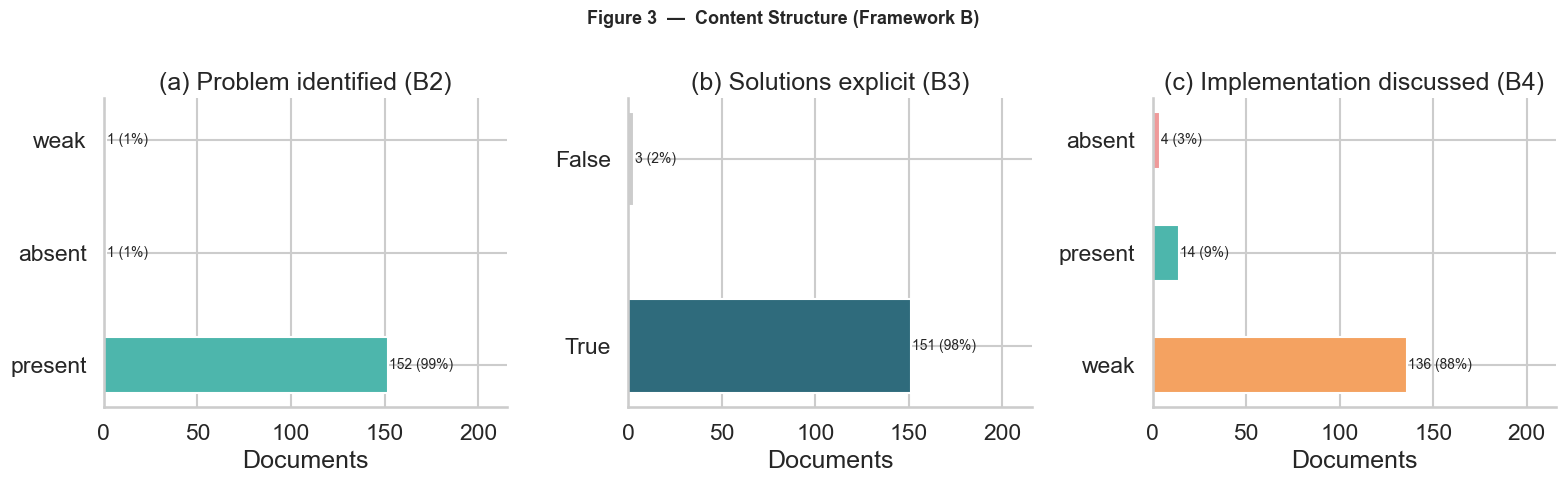

,Present (n),%
Dimension,,
B2 Problem identified,154,100%
B3 Solutions explicit,151,98%
B4 Implementation discussed,154,100%


In [4]:
STATUS_COLORS = {
    'present': C_AGREE,  'weak': C_ACCENT,    'absent': C_DISAGREE,
    'True':    C_PRIMARY, 'False': '#cccccc',
    True:      C_PRIMARY, False:  '#cccccc',
}

cols_b = [
    ('B2_problem_identified',    '(a) Problem identified (B2)'),
    ('B3_solutions_explicit',    '(b) Solutions explicit (B3)'),
    ('B4_implementation_status', '(c) Implementation discussed (B4)'),
]
available_b = [(c, t) for c, t in cols_b if c in analysis_df.columns]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, title) in zip(axes, available_b):
    vc = analysis_df[col].value_counts()
    bar_colors = [STATUS_COLORS.get(v, C_PRIMARY) for v in vc.index]
    bars = ax.barh([str(v) for v in vc.index], vc.values, color=bar_colors, edgecolor='white', height=0.5)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{v} ({v / len(analysis_df):.0%})', va='center', fontsize=10)
    ax.set_xlim(0, len(analysis_df) * 1.4)
    ax.set_xlabel('Documents')
    ax.set_title(title)
for ax in axes[len(available_b):]:
    ax.set_visible(False)

fig.suptitle('Figure 3  —  Content Structure (Framework B)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
rows_b = []
for col, label in [
    ('B2_problem_identified',    'B2 Problem identified'),
    ('B3_solutions_explicit',    'B3 Solutions explicit'),
    ('B4_implementation_status', 'B4 Implementation discussed'),
]:
    if col not in analysis_df.columns:
        continue
    s = analysis_df[col]
    n = int((s == 'present').sum()) if s.dtype == object else int(s.astype(bool).sum())
    rows_b.append({'Dimension': label, 'Present (n)': n, '%': f'{n / len(analysis_df):.0%}'})
if rows_b:
    display(pd.DataFrame(rows_b).set_index('Dimension'))

## 4. Action Orientation (Frameworks C & D)

The **bridging role** (C) assesses whether a brief specifies *how* to act (C5 procedural clarity), *who* should act (C6 responsibility), and what outcomes are anticipated (C7). The **facilitating role** (D) extends this by asking whether the brief discusses broader impacts (D8), trade-offs between options (D9), and concrete policy alternatives (D10).

Together these six dimensions measure the brief's *action-orientation* — its capacity to guide policy actors toward concrete decisions. Figure 4 shows the percentage of documents meeting each criterion; the dashed line marks the 50% threshold. Note: C5 reflects procedural clarity or, where that field is absent, implementation status as a proxy.

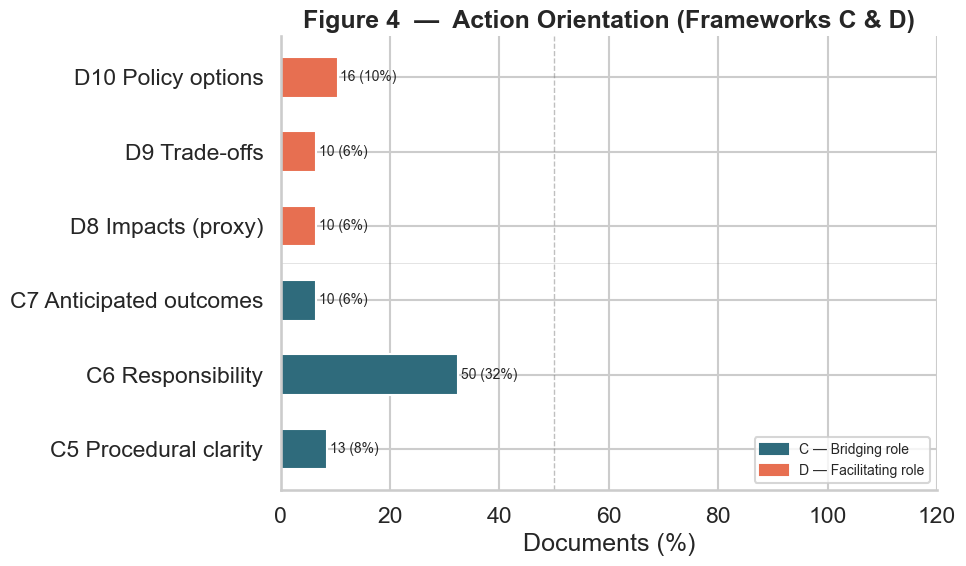

,Present (n),%
Dimension,,
C5 Procedural clarity,13,8%
C6 Responsibility,50,32%
C7 Anticipated outcomes,10,6%
D8 Impacts (proxy),10,6%
D9 Trade-offs,10,6%
D10 Policy options,16,10%


In [5]:
indicators_cd = [
    ('C5 Procedural clarity',   'C5_procedural_clarity',    'C'),
    ('C6 Responsibility',       'C6_responsibility',         'C'),
    ('C7 Anticipated outcomes', 'C7_anticipated_outcomes',   'C'),
    ('D8 Impacts (proxy)',      'D8_impacts_proxy',          'D'),
    ('D9 Trade-offs',           'D9_tradeoffs',              'D'),
    ('D10 Policy options',      'D10_policy_options',        'D'),
]

rows_cd = []
for label, col, group in indicators_cd:
    if col not in analysis_df.columns:
        continue
    s   = analysis_df[col]
    pct = float((s == 'present').mean()) if 'present' in s.values else float(s.astype(bool).mean())
    rows_cd.append({'label': label, 'pct': pct * 100, 'n': int(round(pct * len(analysis_df))), 'group': group})

if rows_cd:
    df_cd  = pd.DataFrame(rows_cd)
    colors = [C_PRIMARY if g == 'C' else C_WARM for g in df_cd['group']]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(df_cd['label'], df_cd['pct'], color=colors, edgecolor='white', height=0.55)
    for bar, row in zip(bars, df_cd.itertuples()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{row.n} ({row.pct:.0f}%)', va='center', fontsize=10)
    ax.set_xlim(0, 120)
    ax.set_xlabel('Documents (%)')
    ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(2.5, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    p_c = mpatches.Patch(color=C_PRIMARY, label='C — Bridging role')
    p_d = mpatches.Patch(color=C_WARM,    label='D — Facilitating role')
    ax.legend(handles=[p_c, p_d], loc='lower right', fontsize=10)
    ax.set_title('Figure 4  —  Action Orientation (Frameworks C & D)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    display(
        df_cd[['label', 'n', 'pct']]
        .rename(columns={'label': 'Dimension', 'n': 'Present (n)', 'pct': '%'})
        .assign(**{'%': df_cd['pct'].apply(lambda x: f'{x:.0f}%')})
        .set_index('Dimension')
    )

## 5. Accessibility (Framework E)

Dimensions E12–E14 measure language complexity indicators that affect how easily a non-specialist policy audience can engage with a brief. Average sentence length and lexical diversity describe structural text complexity; Flesch Reading Ease and Flesch-Kincaid Grade Level provide standardized readability benchmarks (higher Flesch = easier; higher FK grade = harder).

Table 3 summarizes the key statistics; Figure 5 shows the full distribution of each indicator across the corpus.

**Table 3 — Accessibility indicator summary statistics (Framework E)**

,mean,median,std,min,max
Avg sentence length (words),22.65,22.52,4.78,12.23,45.78
Lexical diversity,0.36,0.37,0.12,0.10,0.63
Flesch reading ease,20.60,20.24,8.89,-14.51,44.38
Flesch-Kincaid grade level,15.68,15.70,1.84,10.97,24.67


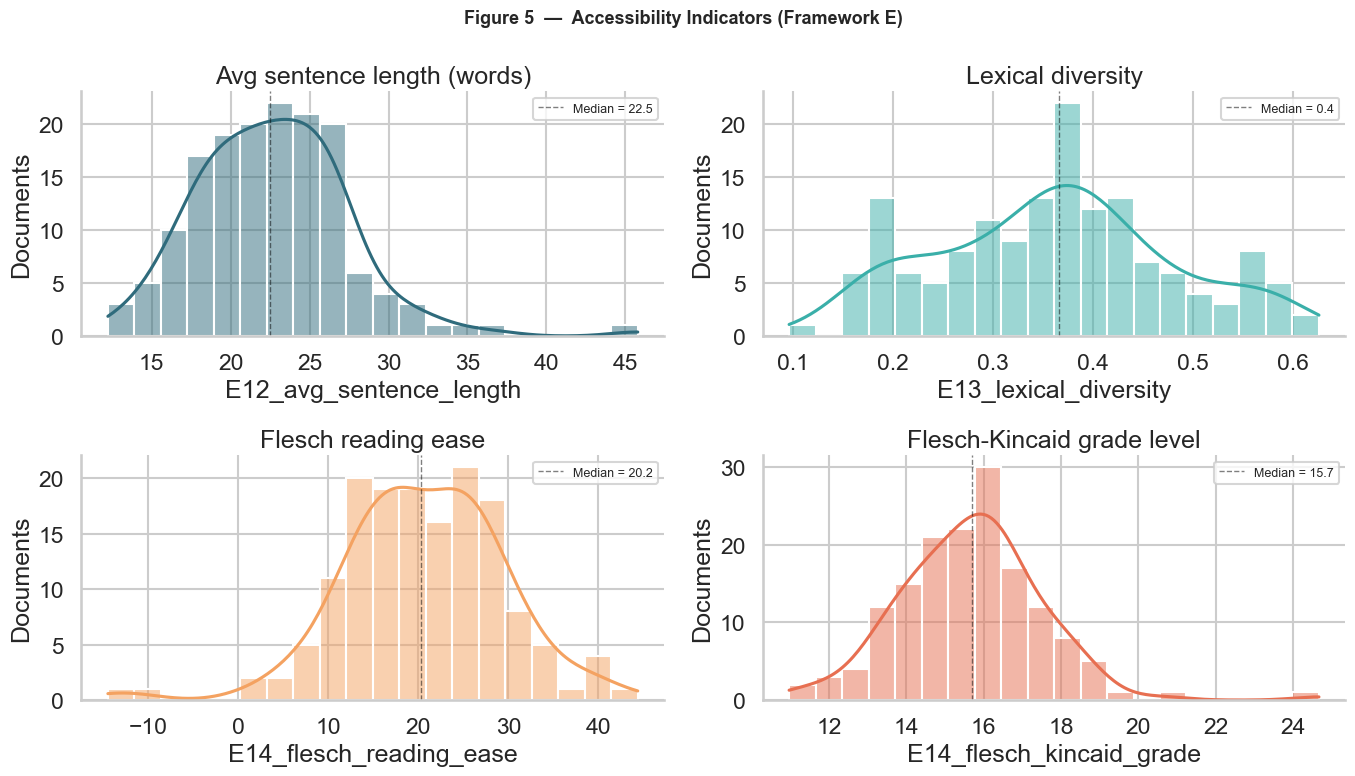

In [6]:
access_items = [
    ('Avg sentence length (words)', 'E12_avg_sentence_length'),
    ('Lexical diversity',           'E13_lexical_diversity'),
    ('Flesch reading ease',         'E14_flesch_reading_ease'),
    ('Flesch-Kincaid grade level',  'E14_flesch_kincaid_grade'),
]
avail_a = [(l, c) for l, c in access_items if c in analysis_df.columns and analysis_df[c].notna().any()]

if avail_a:
    stats_a = pd.DataFrame({
        l: analysis_df[c].describe()[['mean', '50%', 'std', 'min', 'max']]
        for l, c in avail_a
    }).T.rename(columns={'50%': 'median'}).round(2)
    display(Markdown('**Table 3 — Accessibility indicator summary statistics (Framework E)**'))
    display(stats_a)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    palette = [C_PRIMARY, C_SECONDARY, C_ACCENT, C_WARM]
    for ax, (label, col), c in zip(axes, avail_a, palette):
        data = analysis_df[col].dropna()
        sns.histplot(data, bins=20, kde=True, ax=ax, color=c)
        ax.axvline(data.median(), color='black', linestyle='--', linewidth=1,
                   alpha=0.5, label=f'Median = {data.median():.1f}')
        ax.set_title(label)
        ax.set_ylabel('Documents')
        ax.legend(fontsize=9)
    for ax in axes[len(avail_a):]:
        ax.set_visible(False)

    fig.suptitle('Figure 5  —  Accessibility Indicators (Framework E)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Accessibility columns not available.')

## 6. Narrative & Transparency (Frameworks F & G)

**F15 Narrative hook** assesses whether the brief opens with an engaging device — a striking statistic, anecdote, scenario, or question — intended to draw the reader in before the substantive content. The hook-type breakdown shows which rhetorical devices are most common among briefs that use them.

**G16 Funding disclosure** and **G18 Contact information** are basic transparency indicators: does the brief acknowledge who funded the underlying research, and does it provide a means for policy actors to reach the authors?

Figure 6 shows these three dimensions as a combined panel.

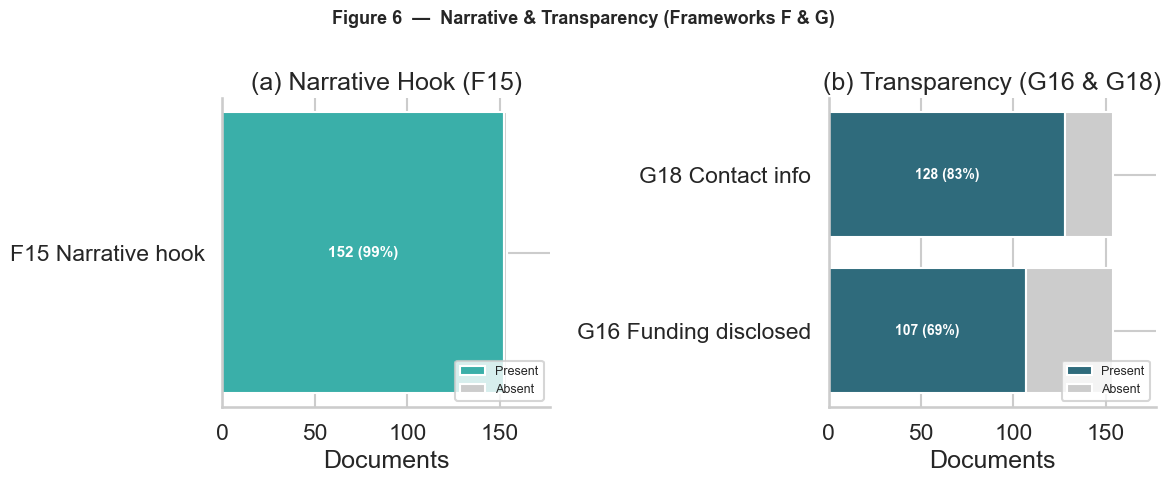

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Narrative hook: present vs absent (horizontal stacked)
if 'F15_narrative_hook' in analysis_df.columns:
    hook_n  = int(analysis_df['F15_narrative_hook'].astype(bool).sum())
    hook_ab = len(analysis_df) - hook_n
    axes[0].barh(['F15 Narrative hook'], [hook_n],  color=C_SECONDARY, edgecolor='white', label='Present')
    axes[0].barh(['F15 Narrative hook'], [hook_ab], left=[hook_n], color='#cccccc', edgecolor='white', label='Absent')
    axes[0].text(hook_n / 2, 0, f'{hook_n} ({hook_n / len(analysis_df):.0%})',
                 ha='center', va='center', color='white', fontsize=11, fontweight='bold')
    axes[0].set_xlim(0, len(analysis_df) * 1.15)
    axes[0].set_xlabel('Documents')
    axes[0].set_title('(a) Narrative Hook (F15)')
    axes[0].legend(fontsize=9, loc='lower right')
else:
    axes[0].set_visible(False)

# (b) Transparency: G16 funding + G18 contact (horizontal stacked)
transp_items_g = [('G16 Funding disclosed', 'G16_funding'), ('G18 Contact info', 'G18_contact_info')]
t_rows = []
for label, col in transp_items_g:
    if col not in analysis_df.columns:
        continue
    s = analysis_df[col]
    n = int(s.astype(bool).sum()) if s.notna().any() else 0
    t_rows.append((label, n, len(analysis_df) - n))

if t_rows:
    t_labels  = [r[0] for r in t_rows]
    t_present = [r[1] for r in t_rows]
    t_absent  = [r[2] for r in t_rows]
    axes[1].barh(t_labels, t_present, color=C_PRIMARY,   edgecolor='white', label='Present')
    axes[1].barh(t_labels, t_absent,  left=t_present, color='#cccccc', edgecolor='white', label='Absent')
    for i, p in enumerate(t_present):
        axes[1].text(p / 2, i, f'{p} ({p / len(analysis_df):.0%})',
                     ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    axes[1].set_xlim(0, len(analysis_df) * 1.15)
    axes[1].set_xlabel('Documents')
    axes[1].set_title('(b) Transparency (G16 & G18)')
    axes[1].legend(fontsize=9, loc='lower right')
else:
    axes[1].set_visible(False)

fig.suptitle('Figure 6  —  Narrative & Transparency (Frameworks F & G)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Policy-Instrument Frames (Framework H)

Dimensions H19–H23 classify each brief against five canonical policy-instrument frames derived from the theoretical literature:

| # | Frame | Description |
|---|---|---|
| H19 | Command-and-Control | Regulatory mandates, standards, prohibitions |
| H20 | Economic Instruments | Taxes, subsidies, market mechanisms |
| H21 | Self-Regulation | Voluntary standards set by industry/profession |
| H22 | Voluntarism | Voluntary actions without binding standards |
| H23 | Information Strategies | Education, labelling, awareness campaigns |

A brief exhibiting two or more frames constitutes a **policy mix** (H24). Figure 7(a) shows how many documents contain each frame; Figure 7(b) shows the co-occurrence matrix — how often each pair of frames appears together in the same document.

Policy mix (H24, ≥2 frames present): 71 / 154 (46%)


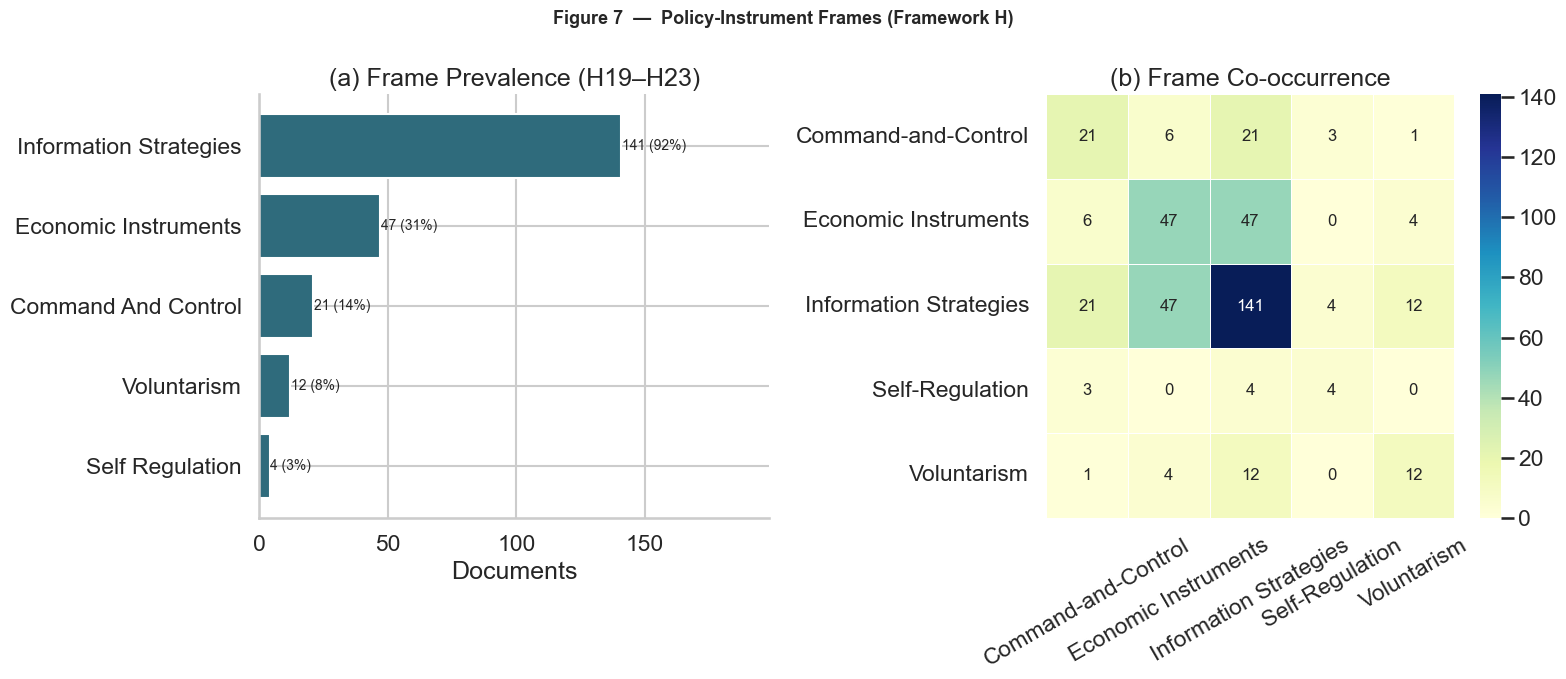

In [8]:
h_cols = [
    c for c in analysis_df.columns
    if c.startswith('H_') and c not in ('H_frames_present_count', 'H24_policy_mix')
]

if h_cols:
    mix_n   = int(analysis_df['H24_policy_mix'].astype(bool).sum()) if 'H24_policy_mix' in analysis_df.columns else 0
    mix_pct = mix_n / len(analysis_df)
    print(f'Policy mix (H24, ≥2 frames present): {mix_n} / {len(analysis_df)} ({mix_pct:.0%})')

    frame_prev = analysis_df[h_cols].sum().sort_values()
    frame_prev.index = [c.replace('H_', '').replace('_', ' ').title() for c in frame_prev.index]

    fig = plt.figure(figsize=(16, 7))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)

    bars = ax1.barh(frame_prev.index, frame_prev.values, color=C_PRIMARY, edgecolor='white')
    for bar, v in zip(bars, frame_prev.values):
        ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{v} ({v / len(analysis_df):.0%})', va='center', fontsize=10)
    ax1.set_xlim(0, frame_prev.values.max() * 1.4 + 1)
    ax1.set_xlabel('Documents')
    ax1.set_title('(a) Frame Prevalence (H19–H23)')

    if len(frames):
        _fp2  = frames[frames['decision'] == 'present']
        _pm   = _fp2.assign(v=1).pivot_table(
            index='doc_id', columns='frame_label', values='v', fill_value=0
        )
        _cooc = _pm.T.dot(_pm)
        sns.heatmap(
            _cooc, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, ax=ax2, annot_kws={'size': 12},
        )
        ax2.set_title('(b) Frame Co-occurrence')
        ax2.set_xlabel('')
        ax2.set_ylabel('')
        ax2.tick_params(axis='x', rotation=30)

    fig.suptitle('Figure 7  —  Policy-Instrument Frames (Framework H)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Frame columns (H_*) not found in analysis_df — check frames.csv and setup cell.')